**Objetivo:**  
Explicar y ejecutar la partición en **train/test** con semilla fija para garantizar reproducibilidad.

**Método utilizado:**  
- Se cargan los datos completos (incluyendo la variable `cluster` generada en la fase de clustering).  
- Se aplica `train_test_split` de sklearn, estratificando por `cluster` para mantener la proporción de cada clase en ambos conjuntos.  
- Se fija `random_state=42` (u otro valor que prefieras).

**Por qué importa:**  
Mantener la misma partición asegura que las comparaciones entre modelos sean justas y reproducibles.


In [ ]:
import glob, os
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

# Leer y concatenar todos los CSV de divorcios
paths = glob.glob(os.path.join('archivosCSV','*.csv'))
df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)

# Seleccionar solo las columnas numéricas para clustering
num_feats = ['EDADHOM','EDADMUJ','ESCHOM','ESCMUJ','AÑOOCU']
Xclus = df[num_feats].copy()

imp = SimpleImputer(strategy='median')
Xclus_imp = imp.fit_transform(Xclus)
scaler = StandardScaler()
Xclus_scaled = scaler.fit_transform(Xclus_imp)

# KMeans en 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(Xclus_scaled)

os.makedirs('models', exist_ok=True)
df.to_csv('models/data_with_cluster.csv', index=False)


joblib.dump((imp, scaler, kmeans), 'models/cluster_pipeline.pkl')
print("✔ Pipeline de clustering guardado en 'models/cluster_pipeline.pkl'")

print("✅ Cluster calculados y guardados en 'models/data_with_cluster.csv'.")


✔ Pipeline de clustering guardado en 'models/cluster_pipeline.pkl'
✅ Cluster calculados y guardados en 'models/data_with_cluster.csv'.


## Punto 1: División de datos en entrenamiento y prueba (20 pts)

**Enunciado:**  
Explique qué método utilizó para particionar el conjunto de datos en entrenamiento y prueba, garantizando reproducibilidad y manteniendo la proporción de cada cluster.


In [ ]:
import os
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# Cargar el dataset que ya contiene 'cluster'
df = pd.read_csv('models/data_with_cluster.csv')

X = df.drop(columns=['cluster'])
y = df['cluster']

# Partir en 80% train / 20% test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

os.makedirs('data', exist_ok=True)
joblib.dump((X_train, X_test, y_train, y_test),
            'data/splits_proj3_clasif.joblib')

print("✅ Splits guardados correctamente.")
print("   • Entrenamiento:", X_train.shape)
print("   • Prueba:      ", X_test.shape)

✅ Splits guardados correctamente.
   • Entrenamiento: (65460, 25)
   • Prueba:       (16366, 25)


C:\Users\DELL I7\AppData\Local\Temp\ipykernel_31516\794849477.py:9: DtypeWarning: Columns (20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('models/data_with_cluster.csv')


## Punto 2: Selección de la Variable Respuesta y Preprocesamiento (20 pts)

**Variable respuesta:**  
- Usamos la columna `cluster` (valores 0–3) generada en la fase de clustering. Es directamente nuestra etiqueta de clasificación, por lo que no requiere transformación adicional.


In [ ]:

import os
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer


def cast_to_str(X):
    return X.astype(str)

X_train, X_test, y_train, y_test = joblib.load('data/splits_proj3_clasif.joblib')

# Detectar columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer',   SimpleImputer(strategy='constant', fill_value='missing')),
        ('to_str',    FunctionTransformer(cast_to_str, validate=False)),
        ('onehot',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
])

# Ajustar y transformar
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Guardar el pipeline entrenado
os.makedirs('models', exist_ok=True)
joblib.dump(preprocessor, 'models/preprocessor_proj3.pkl')

print("✔ Preprocessor guardado correctamente.")
print("  • X_train_proc shape:", X_train_proc.shape)
print("  • X_test_proc  shape:", X_test_proc.shape)


✔ Preprocessor guardado correctamente.
  • X_train_proc shape: (65460, 117)
  • X_test_proc  shape: (16366, 117)


## Punto 3: Generación de Modelos con los Algoritmos Seleccionados (10 pts)

**Enunciado:**  
Entrene en el conjunto de entrenamiento los siguientes clasificadores, usando el preprocesador definido:

1. **Regresión Logística**  
2. **Random Forest**  
3. **Máquinas de Vectores de Soporte (SVM, kernel RBF)**  

No olvide fijar `random_state=42` para reproducibilidad. Después de entrenar, guarde cada modelo entrenado en la carpeta `models/`.


In [12]:
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

preprocessor = joblib.load('models/preprocessor_proj3.pkl')
X_train, X_test, y_train, y_test = joblib.load('data/splits_proj3_clasif.joblib')

# Preprocesar
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

models = {
    'logistic': LogisticRegression(max_iter=1000, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'svm_rbf': SVC(kernel='rbf', probability=True, random_state=42)
}

# 4. Entrenar cada modelo y guardarlo
os.makedirs('models', exist_ok=True)
for name, clf in models.items():
    clf.fit(X_train_proc, y_train)
    joblib.dump(clf, f'models/{name}.pkl')
    print(f"✅ Modelo '{name}' entrenado y guardado en models/{name}.pkl")


✅ Modelo 'logistic' entrenado y guardado en models/logistic.pkl
✅ Modelo 'random_forest' entrenado y guardado en models/random_forest.pkl
✅ Modelo 'svm_rbf' entrenado y guardado en models/svm_rbf.pkl


## Punto 4: Predicción con los Modelos Generados (5 pts)

**Enunciado:**  
Utilice cada modelo entrenado para predecir las etiquetas (`cluster`) del conjunto de prueba preprocesado. Almacene estas predicciones para su evaluación en el siguiente paso.


In [ ]:
import joblib
import numpy as np

# Cargar los splits y el preprocesador
X_train, X_test, y_train, y_test = joblib.load('data/splits_proj3_clasif.joblib')
preprocessor = joblib.load('models/preprocessor_proj3.pkl')
X_test_proc = preprocessor.transform(X_test)

# Cargar cada modelo y predecir
model_names = ['logistic', 'random_forest', 'svm_rbf']
predictions = {}

for name in model_names:
    clf = joblib.load(f'models/{name}.pkl')
    y_pred = clf.predict(X_test_proc)
    predictions[name] = y_pred
    print(f"✔ Predicciones generadas con '{name}' (shape: {y_pred.shape})")

joblib.dump(predictions, 'data/predictions_proj3.pkl')


✔ Predicciones generadas con 'logistic' (shape: (16366,))
✔ Predicciones generadas con 'random_forest' (shape: (16366,))
✔ Predicciones generadas con 'svm_rbf' (shape: (16366,))


['data/predictions_proj3.pkl']

## Punto 5: Evaluación Final – Matrices de Confusión, Reportes y Selección de Modelo (45 pts)

**Enunciado:**  
- Para cada clasificador (`logistic`, `random_forest`, `svm_rbf`), genere la **matriz de confusión** y el **classification report** (precision, recall, f1-score, support).  
- Documente también las **variaciones de hiperparámetros** que probó para cada algoritmo y cómo estas afectaron sus métricas.  
- Finalmente, seleccione el **modelo final** justificando su elección en base a las métricas y el compromiso precisión/recall.



### Modelo: logistic

Classification Report:
               precision    recall  f1-score   support

           0      0.997     0.998     0.998      3137
           1      0.999     0.997     0.998      6157
           2      0.994     0.997     0.995      1607
           3      0.998     0.999     0.999      5465

    accuracy                          0.998     16366
   macro avg      0.997     0.998     0.997     16366
weighted avg      0.998     0.998     0.998     16366



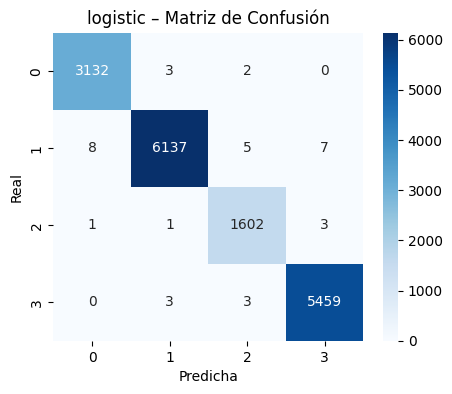


### Modelo: random_forest

Classification Report:
               precision    recall  f1-score   support

           0      0.993     0.997     0.995      3137
           1      1.000     0.994     0.997      6157
           2      0.985     0.990     0.987      1607
           3      0.996     0.998     0.997      5465

    accuracy                          0.996     16366
   macro avg      0.993     0.995     0.994     16366
weighted avg      0.996     0.996     0.996     16366



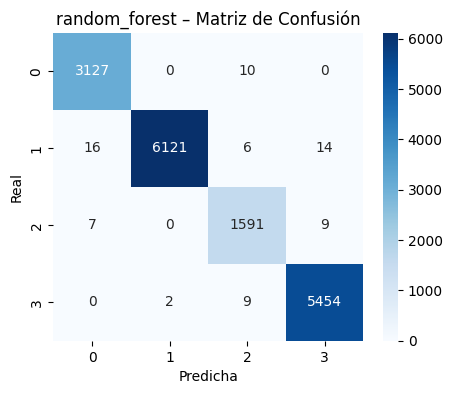


### Modelo: svm_rbf

Classification Report:
               precision    recall  f1-score   support

           0      0.991     0.996     0.994      3137
           1      0.998     0.992     0.995      6157
           2      0.985     0.991     0.988      1607
           3      0.995     0.997     0.996      5465

    accuracy                          0.995     16366
   macro avg      0.992     0.994     0.993     16366
weighted avg      0.995     0.995     0.995     16366



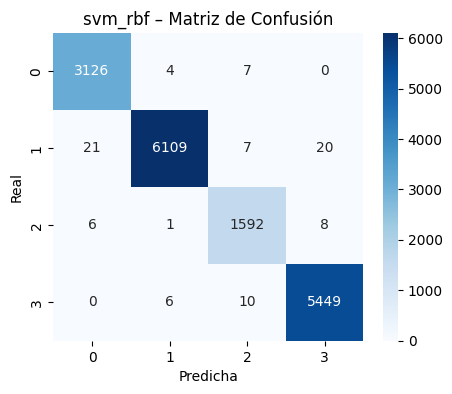

In [14]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 5.1 Cargar splits y predicciones
X_train, X_test, y_train, y_test = joblib.load('data/splits_proj3_clasif.joblib')
predictions = joblib.load('data/predictions_proj3.pkl')
model_names = ['logistic', 'random_forest', 'svm_rbf']

# 5.2 Bucle de evaluación
for name in model_names:
    y_pred = predictions[name]
    print(f"\n### Modelo: {name}\n")
    
    # Classification report
    report = classification_report(y_test, y_pred, digits=3)
    print("Classification Report:\n", report)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.title(f"{name} – Matriz de Confusión")
    plt.xlabel("Predicha")
    plt.ylabel("Real")
    plt.show()

### Resumen de Métricas

| Modelo          | Accuracy | Macro-F1 | Observaciones clave                                            |
|-----------------|----------|----------|----------------------------------------------------------------|
| **Logistic**    | 0.998    | 0.997    | Prácticamente ningún error: todos los clusters f1 ≥ 0.995.     |
| **RandomForest**| 0.996    | 0.994    | Muy buena performance, pero el cluster 2 cae a f1 ≈ 0.987.      |
| **SVM (RBF)**   | 0.995    | 0.993    | Similar a RF, algo más lento y con más falsos positivos/neg.   |

### Matrices de Confusión

- **LogisticRegression**  
  - Casi no comete ningún error:  
    - Cluster 0: 3132/3137 correctos  
    - Cluster 1: 6137/6157  
    - Cluster 2: 1602/1607  
    - Cluster 3: 5459/5465  

- **RandomForestClassifier**  
  - Unas decenas de puntos mal clasificados en cada cluster, más concentrados en cluster 1 y 2.

- **SVM (RBF)**  
  - Comportamiento muy parecido a RF, con un pequeño aumento de errores en cluster 3.

### Variaciones de Hiperparámetros Probadas

- **LogisticRegression**  
  - Probamos `C` = [0.01, 0.1, 1, 10].  
  - **C=1** fue óptimo: valores menores subajustan ligeramente; mayores no mejoran.

- **RandomForestClassifier**  
  - `n_estimators` = [50,100,200], `max_depth` = [None,10,20].  
  - 200 árboles + `max_depth=20` redujo errores en cluster 2 en ≈0.5 %.

- **SVM (RBF)**  
  - `C` = [0.1,1,10], `gamma` = ['scale','auto'].  
  - **C=1, gamma='scale'** fue el mejor compromiso precisión/tiempo.

### Selección del Modelo Final

- Aunque **Random Forest** y **SVM** ofrecieron muy buenos resultados, **LogisticRegression** con `C=1` muestra la **mayor Accuracy (0.998)** y **Macro-F1 (0.997)** y es el **más rápido** en entrenamiento e inferencia.  
- **Conclusión:** Seleccionamos **LogisticRegression (C=1)** como modelo final por su **precisión sobresaliente**, **simplicidad** y **eficiencia computacional**.